Epoch 0, Loss: 0.3497755003962552
Epoch 1000, Loss: 0.015141961794178831
Epoch 2000, Loss: 0.011778223947584824
Epoch 3000, Loss: 0.010935425442285727
Epoch 4000, Loss: 0.010580101062679266


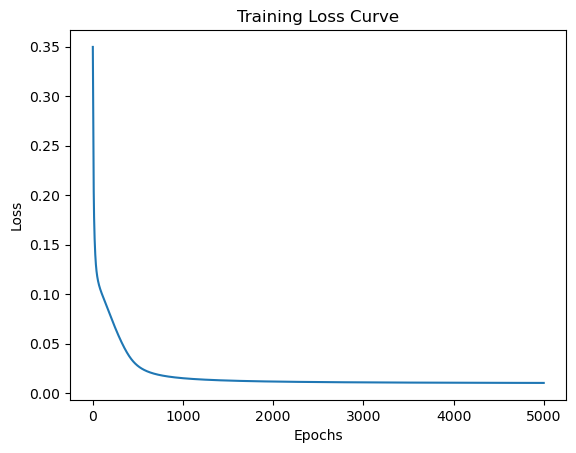

Test Accuracy: 100.00%


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load the Iris dataset
data = load_iris()
X = data.data
y = data.target

# Preprocess data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# One-hot encoding for target variable
y_one_hot = np.eye(3)[y]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_one_hot, test_size=0.2, random_state=42)

# Neural Network Architecture
input_size = X_train.shape[1]  # 4 features (input layer)
hidden_size = 5  # number of hidden neurons
output_size = 3  # 3 classes (output layer)

# Initialize weights and biases
np.random.seed(42)
W1 = np.random.randn(input_size, hidden_size)
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size)
b2 = np.zeros((1, output_size))

# Activation function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# Loss function (Mean Squared Error)
def compute_loss(y_pred, y_true):
    return np.mean((y_pred - y_true) ** 2)

# Training the Neural Network
epochs = 5000
learning_rate = 0.01
losses = []

for epoch in range(epochs):
    # Forward Propagation
    z1 = np.dot(X_train, W1) + b1
    a1 = sigmoid(z1)
    z2 = np.dot(a1, W2) + b2
    a2 = sigmoid(z2)  # Output layer
    
    # Compute loss
    loss = compute_loss(a2, y_train)
    losses.append(loss)
    
    # Backpropagation
    error_output = a2 - y_train
    dZ2 = error_output * sigmoid_derivative(a2)
    dW2 = np.dot(a1.T, dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)
    
    error_hidden = np.dot(dZ2, W2.T)
    dZ1 = error_hidden * sigmoid_derivative(a1)
    dW1 = np.dot(X_train.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)
    
    # Update weights and biases using gradient descent
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    
    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss}")

# Plotting the loss curve
plt.plot(losses)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.show()

# Testing the model
z1_test = np.dot(X_test, W1) + b1
a1_test = sigmoid(z1_test)
z2_test = np.dot(a1_test, W2) + b2
a2_test = sigmoid(z2_test)

# Convert predictions back to classes
predictions = np.argmax(a2_test, axis=1)
true_labels = np.argmax(y_test, axis=1)

# Calculate accuracy
accuracy = accuracy_score(true_labels, predictions)
print(f"Test Accuracy: {accuracy * 100:.2f}%")
